In [50]:
import pandas as pd
import os
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

In [51]:

# Cargar los datos desde el archivo Excel
df = pd.read_csv("../data/processed/kakebo_merged.csv", sep=";")
df

,MES,MONTO,año
0,MES ENERO,14057968,2025
1,MES FEBRERO,3310580,2025
2,MES MARZO,3072536,2025
3,MES ABRIL,3455498,2025
4,MES MAYO,3385952,2025
5,MES JUNIO,3167049,2025
6,MES JULIO,3337777,2025
7,MES AGOSTO,4465156,2025
8,MES SEPTIEMBRE,5206932,2025
9,MES OCTUBRE,6291127,2025


In [52]:
# Crear columna "No MES" basada en el nombre del mes
meses = [
    "ENERO", "FEBRERO", "MARZO", "ABRIL", "MAYO", "JUNIO",
    "JULIO", "AGOSTO", "SEPTIEMBRE", "OCTUBRE", "NOVIEMBRE", "DICIEMBRE"
]
mapa_meses = {mes: i + 1 for i, mes in enumerate(meses)}

df["No MES"] = (
    df["MES"]
    .str.replace("MES ", "", regex=False)
    .str.strip()
    .map(mapa_meses)
)

df



,MES,MONTO,año,No MES
0,MES ENERO,14057968,2025,1
1,MES FEBRERO,3310580,2025,2
2,MES MARZO,3072536,2025,3
3,MES ABRIL,3455498,2025,4
4,MES MAYO,3385952,2025,5
5,MES JUNIO,3167049,2025,6
6,MES JULIO,3337777,2025,7
7,MES AGOSTO,4465156,2025,8
8,MES SEPTIEMBRE,5206932,2025,9
9,MES OCTUBRE,6291127,2025,10


In [53]:
df.mean

<bound method DataFrame.mean of                MES     MONTO   año  No MES
0        MES ENERO  14057968  2025       1
1      MES FEBRERO   3310580  2025       2
2        MES MARZO   3072536  2025       3
3        MES ABRIL   3455498  2025       4
4         MES MAYO   3385952  2025       5
5        MES JUNIO   3167049  2025       6
6        MES JULIO   3337777  2025       7
7       MES AGOSTO   4465156  2025       8
8   MES SEPTIEMBRE   5206932  2025       9
9      MES OCTUBRE   6291127  2025      10
10   MES NOVIEMBRE   5725800  2025      11
11   MES DICIEMBRE   6068471  2025      12
12       MES ENERO   8807436  2026       1
13     MES FEBRERO   4331947  2026       2>

In [54]:
df.describe()

,MONTO,año,No MES
count,1.400000e+01,14.000000,14.000000
mean,5.334588e+06,2025.142857,5.785714
std,2.997040e+06,0.363137,3.786181
min,3.072536e+06,2025.000000,1.000000
25%,3.349821e+06,2025.000000,2.250000
50%,4.398552e+06,2025.000000,5.500000
75%,5.982803e+06,2025.000000,8.750000
max,1.405797e+07,2026.000000,12.000000


R2: 1.0000
MAE: 0.00
RMSE: 0.00


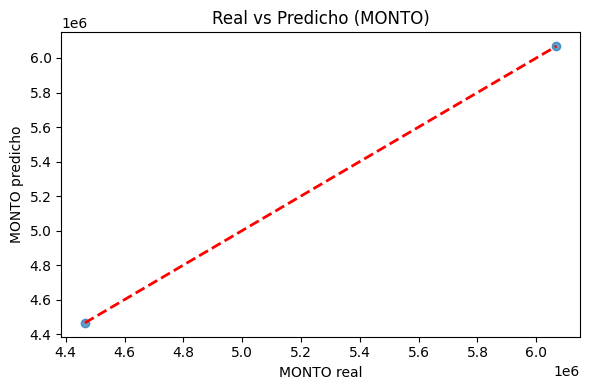

Porcentaje de error por muestra (%): [0. 0.]
Mejor grado: 1, R2 CV: 1.0000


c:\Users\WAGNER FERNÁNDEZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.

c:\Users\WAGNER FERNÁNDEZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.

c:\Users\WAGNER FERNÁNDEZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.

c:\Users\WAGNER FERNÁNDEZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.

c:\Users\WAGNER FERNÁNDEZ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning:

R^2 score is not well-defined with

R2 (test): 1.0000
MAE (test): 0.00
RMSE (test): 0.00
✅ El modelo alcanza más del 75% en aciertos.


In [55]:
# Filtrar outlier: ENERO 2025
df_clean = df.copy()
mask_outlier = (df_clean["año"] == 2025) & (df_clean["MES"].str.contains("ENERO", case=False, na=False))
df_clean = df_clean[~mask_outlier]

# Orden temporal para lags/rolling
df_clean = df_clean.sort_values(["año", "No MES"]).reset_index(drop=True)

# Features cíclicas del mes
df_clean["mes_sin"] = np.sin(2 * np.pi * df_clean["No MES"] / 12)
df_clean["mes_cos"] = np.cos(2 * np.pi * df_clean["No MES"] / 12)

# Lags y promedios móviles
df_clean["lag_1"] = df_clean["MONTO"].shift(1)
df_clean["lag_2"] = df_clean["MONTO"].shift(2)
df_clean["lag_3"] = df_clean["MONTO"].shift(3)
df_clean["roll_3"] = df_clean["MONTO"].rolling(3).mean()
df_clean["roll_6"] = df_clean["MONTO"].rolling(6).mean()

# Quitar filas con NaN por lags/rolling
df_model = df_clean.dropna().copy()

# Variables: predecir MONTO con nuevas features
feature_cols = ["No MES", "año", "mes_sin", "mes_cos", "lag_1", "lag_2", "lag_3", "roll_3", "roll_6"]
X = df_model[feature_cols]
y = df_model["MONTO"]

# Split simple
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicción y métricas
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Gráfica Real vs Predicho
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("MONTO real")
plt.ylabel("MONTO predicho")
plt.title("Real vs Predicho (MONTO)")
plt.tight_layout()
plt.show()


# Porcentaje de error por muestra y promedio
porcentaje_error = (y_pred - y_test.values) / y_test.values * 100
porcentaje_error_abs = np.abs(porcentaje_error)

print("Porcentaje de error por muestra (%):", np.round(porcentaje_error, 2))
# Probar distintos grados y elegir el mejor por R2 en validación cruzada
mejor_grado = None
mejor_r2 = -np.inf

for grado in range(1, 6):
    modelo_poly = make_pipeline(PolynomialFeatures(grado, include_bias=False), LinearRegression())
    scores = cross_val_score(modelo_poly, X, y, cv=5, scoring="r2")
    r2_cv = np.nanmean(scores)
    if np.isfinite(r2_cv) and r2_cv > mejor_r2:
        mejor_r2 = r2_cv
        mejor_grado = grado

if mejor_grado is None:
    mejor_grado = 1
    mejor_r2 = float("nan")

print(f"Mejor grado: {mejor_grado}, R2 CV: {mejor_r2:.4f}")

# Entrenar con el mejor grado y evaluar en test
modelo_poly = make_pipeline(PolynomialFeatures(mejor_grado, include_bias=False), LinearRegression())
modelo_poly.fit(X_train, y_train)
y_pred_poly = modelo_poly.predict(X_test)
modelo_poly.fit(X_train, y_train)
y_pred_poly = modelo_poly.predict(X_test)

r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f"R2 (test): {r2_poly:.4f}")
print(f"MAE (test): {mae_poly:.2f}")
print(f"RMSE (test): {rmse_poly:.2f}")

if r2_poly >= 0.75:
    print("✅ El modelo alcanza más del 75% en aciertos.")
else:
    print("❌ El modelo no alcanza más del 75% en aciertos.")    
    


In [56]:
# Porcentajes de predicción basados en métricas
media_y = y_test.mean()

porcentaje_r2 = r2 * 100
porcentaje_mae = (1 - (mae / media_y)) * 100
porcentaje_rmse = (1 - (rmse / media_y)) * 100

resumen_porcentajes = pd.DataFrame({
    "Metrica": ["R2", "MAE", "RMSE"],
    "Porcentaje (%)": [porcentaje_r2, porcentaje_mae, porcentaje_rmse]
})

resumen_porcentajes

,Metrica,Porcentaje (%)
0,R2,100.0
1,MAE,100.0
2,RMSE,100.0


In [57]:
# Construir histórico con columnas necesarias
df_hist_actual = df.copy()
df_hist_actual["TIPO"] = None
df_hist_actual["MONTO_REAL"] = df_hist_actual["MONTO"]

# Crear la fila de predicción del siguiente mes
ultima_fila = df_clean.iloc[-1]
ultimo_mes = int(ultima_fila["No MES"])
ultimo_anio = int(ultima_fila["año"])

sig_mes = 1 if ultimo_mes == 12 else ultimo_mes + 1
sig_anio = ultimo_anio + 1 if ultimo_mes == 12 else ultimo_anio

mes_sin = np.sin(2 * np.pi * sig_mes / 12)
mes_cos = np.cos(2 * np.pi * sig_mes / 12)

lag_1 = float(ultima_fila["MONTO"])
lag_2 = float(ultima_fila["lag_1"])
lag_3 = float(ultima_fila["lag_2"])
roll_3 = df_clean["MONTO"].tail(3).mean()
roll_6 = df_clean["MONTO"].tail(6).mean()

fila_features = pd.DataFrame([{
	"No MES": sig_mes,
	"año": sig_anio,
	"mes_sin": mes_sin,
	"mes_cos": mes_cos,
	"lag_1": lag_1,
	"lag_2": lag_2,
	"lag_3": lag_3,
	"roll_3": roll_3,
	"roll_6": roll_6,
}])

monto_pred = float(modelo.predict(fila_features[feature_cols])[0])

fila_pred = pd.DataFrame([{
	"MES": f"MES {meses[sig_mes - 1]}",
	"MONTO": monto_pred,
	"año": sig_anio,
	"No MES": sig_mes,
	"TIPO": "PREDICCION",
	"MONTO_REAL": monto_pred
}])

# DataFrame con datos históricos + predicción del siguiente mes
df_salida = pd.concat([df_hist_actual, fila_pred], ignore_index=True)
df_salida

mask_pred = df_salida["TIPO"].eq("PREDICCION")
df_salida.loc[mask_pred, "MONTO"] = df_salida.loc[mask_pred, "MONTO_REAL"]
df_salida

df_salida["TIPO_DATO"] = df_salida["TIPO"].fillna("REAL")
df_salida = df_salida.rename(columns={"año": "AÑO"})
df_salida = df_salida[["MES", "MONTO", "AÑO", "TIPO_DATO"]]

df_salida.loc[mask_pred, "MONTO"] = df_salida.loc[mask_pred, "MONTO"].round().astype(int)
df_salida["MONTO"] = df_salida["MONTO"].apply(lambda x: f"{int(round(x)):,}".replace(",", "."))

In [58]:
df_salida

,MES,MONTO,AÑO,TIPO_DATO
0,MES ENERO,14.057.968,2025,REAL
1,MES FEBRERO,3.310.580,2025,REAL
2,MES MARZO,3.072.536,2025,REAL
3,MES ABRIL,3.455.498,2025,REAL
4,MES MAYO,3.385.952,2025,REAL
5,MES JUNIO,3.167.049,2025,REAL
6,MES JULIO,3.337.777,2025,REAL
7,MES AGOSTO,4.465.156,2025,REAL
8,MES SEPTIEMBRE,5.206.932,2025,REAL
9,MES OCTUBRE,6.291.127,2025,REAL


In [59]:
df_salida.to_csv("../data/processed/kakebo_pred2.csv", sep=";", index=False)

In [60]:
fig = go.Figure()

df_real = df_salida[df_salida["TIPO_DATO"].eq("REAL")].copy()
df_pred = df_salida[df_salida["TIPO_DATO"].eq("PREDICCION")].copy()

df_real["MES_ANO"] = df_real["MES"] + " " + df_real["AÑO"].astype(str)
df_pred["MES_ANO"] = df_pred["MES"] + " " + df_pred["AÑO"].astype(str)

fig.add_trace(go.Bar(x=df_real["MES_ANO"], y=df_real["MONTO"], name="REAL", marker_color="steelblue"))
fig.add_trace(go.Bar(x=df_pred["MES_ANO"], y=df_pred["MONTO"], name="PREDICCION", marker_color="orange"))

fig.update_layout(
    barmode="group",
    title="Montos reales vs predicción",
    xaxis_title="Mes y año",
    yaxis_title="Monto",
    legend_title="Tipo de dato"
)
fig.show()